# PV + Wind + BESS Hybrid Analysis

This notebook analyzes co-located PV, Wind, and Battery Energy Storage Systems (BESS) behind a shared 10 MW Point of Interconnection (POI).

**Parameterization:**
- **α_tot**: Total overplanting factor = (P_pv + P_wind) / P_POI
- **s_wind**: Wind share of installed capacity = P_wind / (P_pv + P_wind)
- **γ (gamma)**: Battery power ratio = P_bess / P_POI

**Key Features:**
- Battery can charge from both PV and Wind (green from any renewable)
- LP optimization for optimal battery dispatch with perfect foresight
- Fixed 2-hour battery duration
- Proportional curtailment allocation between PV and Wind


In [1]:
import sys
from pathlib import Path

# Add src to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))
from preprocess import build_clean_dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)

print(f"Project root: {project_root}")


Project root: /Users/fynnfroehlich/Master Thesis


## 1. Load Data and Configuration


In [2]:
# Build cleaned dataset using shared preprocessing
df = build_clean_dataset(
    wind_path=project_root / 'data_raw' / 'wind_data.csv',
    pv_path=project_root / 'data_raw' / 'pv_data.csv',
    price_path=project_root / 'data_raw' / 'price_data.csv',
)

print(f'Data shape: {df.shape}')
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f'\nColumns: {df.columns.tolist()}')
df.head()


Data shape: (8760, 4)
Date range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00

Columns: ['timestamp', 'price_eur_per_mwh', 'pv_per_kw', 'wind_per_kw']


,timestamp,price_eur_per_mwh,pv_per_kw,wind_per_kw
0,2024-01-01 00:00:00,0.10,0.00,0.27
1,2024-01-01 01:00:00,0.01,0.00,0.24
2,2024-01-01 02:00:00,0.00,0.00,0.24
3,2024-01-01 03:00:00,-0.01,0.00,0.24
4,2024-01-01 04:00:00,-0.03,0.00,0.25


In [3]:
# Import configuration and analysis modules
from config import (
    POI_CAPACITY_MW,
    CAPEX_PV_EUR_PER_KW,
    CAPEX_WIND_EUR_PER_KW,
    CAPEX_BESS_EUR_PER_KWH,
    OPEX_PV_EUR_PER_KW_PER_YEAR,
    OPEX_WIND_EUR_PER_KW_PER_YEAR,
    OPEX_BESS_EUR_PER_KW_PER_YEAR,
    LIFETIME_PV_YEARS,
    LIFETIME_WIND_YEARS,
    LIFETIME_BESS_YEARS,
    PROJECT_LIFETIME_YEARS,
    WACC_PV_REAL,
    WACC_WIND_REAL,
    WACC_BESS_REAL,
    BESS_ROUNDTRIP_EFF,
    BESS_REPLACEMENT_SHARE,
)

print("=" * 60)
print("TECHNO-ECONOMIC PARAMETERS")
print("=" * 60)
print(f"\nPOI Capacity: {POI_CAPACITY_MW} MW")
print(f"\nPV Parameters:")
print(f"  CAPEX: €{CAPEX_PV_EUR_PER_KW}/kW")
print(f"  OPEX: €{OPEX_PV_EUR_PER_KW_PER_YEAR}/kW/year")
print(f"  Lifetime: {LIFETIME_PV_YEARS} years")
print(f"  WACC: {WACC_PV_REAL*100:.1f}%")
print(f"\nWind Parameters:")
print(f"  CAPEX: €{CAPEX_WIND_EUR_PER_KW}/kW")
print(f"  OPEX: €{OPEX_WIND_EUR_PER_KW_PER_YEAR}/kW/year")
print(f"  Lifetime: {LIFETIME_WIND_YEARS} years")
print(f"  WACC: {WACC_WIND_REAL*100:.1f}%")
print(f"\nBESS Parameters:")
print(f"  CAPEX: €{CAPEX_BESS_EUR_PER_KWH}/kWh")
print(f"  OPEX: €{OPEX_BESS_EUR_PER_KW_PER_YEAR}/kW/year")
print(f"  Lifetime: {LIFETIME_BESS_YEARS} years (then replacement)")
print(f"  WACC: {WACC_BESS_REAL*100:.1f}%")
print(f"  Round-trip efficiency: {BESS_ROUNDTRIP_EFF*100:.0f}%")
print(f"  Replacement cost: {BESS_REPLACEMENT_SHARE*100:.0f}% of initial CAPEX")
print(f"\nProject Lifetime: {PROJECT_LIFETIME_YEARS} years")


TECHNO-ECONOMIC PARAMETERS

POI Capacity: 10.0 MW

PV Parameters:
  CAPEX: €700.0/kW
  OPEX: €13.3/kW/year
  Lifetime: 30 years
  WACC: 3.5%

Wind Parameters:
  CAPEX: €1300.0/kW
  OPEX: €32.0/kW/year
  Lifetime: 25 years
  WACC: 3.9%

BESS Parameters:
  CAPEX: €400.0/kWh
  OPEX: €5.3/kW/year
  Lifetime: 15 years (then replacement)
  WACC: 2.5%
  Round-trip efficiency: 90%
  Replacement cost: 30% of initial CAPEX

Project Lifetime: 30 years


## 2. Single Configuration Test

First, let's test the LP dispatch with a single configuration to verify everything works.


In [4]:
from hybrid_bess_analysis import evaluate_hybrid_bess_single

# Test configuration: α_tot=2.0, s_wind=0.5, γ=0.5 (50% wind, 5 MW battery)
test_result = evaluate_hybrid_bess_single(
    df=df,
    alpha_tot=2.0,
    s_wind=0.5,
    gamma=0.5,
    bess_duration_h=2.0,
    use_lp=True,
    verbose=False,
)

print("=" * 70)
print("TEST CONFIGURATION: α_tot=2.0, s_wind=50%, γ=0.5")
print("=" * 70)
print(f"\nCapacities:")
print(f"  PV: {test_result.pv_capacity_mw:.1f} MW")
print(f"  Wind: {test_result.wind_capacity_mw:.1f} MW")
print(f"  BESS: {test_result.bess_power_mw:.1f} MW / {test_result.bess_energy_mwh:.1f} MWh")
print(f"\nFinancials:")
print(f"  CAPEX Total: €{test_result.capex_total_eur:,.0f}")
print(f"    - PV: €{test_result.capex_pv_eur:,.0f}")
print(f"    - Wind: €{test_result.capex_wind_eur:,.0f}")
print(f"    - BESS: €{test_result.capex_bess_eur:,.0f}")
print(f"  Annual OPEX: €{test_result.annual_opex_total_eur:,.0f}")
print(f"  Annual Revenue (Year 1): €{test_result.annual_revenue_eur:,.0f}")
print(f"  WACC: {test_result.wacc*100:.2f}%")
print(f"  NPV: €{test_result.npv_eur:,.0f}")
print(f"\nEnergy (Year 1):")
print(f"  Total Export: {test_result.annual_export_mwh_total:,.0f} MWh")
print(f"    - PV: {test_result.annual_export_mwh_pv:,.0f} MWh")
print(f"    - Wind: {test_result.annual_export_mwh_wind:,.0f} MWh")
print(f"    - BESS: {test_result.annual_export_mwh_bess:,.0f} MWh")
print(f"  Total Curtailment: {test_result.annual_curtailment_mwh_total:,.0f} MWh")
print(f"    - PV: {test_result.annual_curtailment_mwh_pv:,.0f} MWh")
print(f"    - Wind: {test_result.annual_curtailment_mwh_wind:,.0f} MWh")
print(f"\nBattery Metrics:")
print(f"  Annual Charge: {test_result.annual_charge_mwh:,.0f} MWh")
print(f"  Annual Discharge: {test_result.annual_discharge_mwh:,.0f} MWh")
print(f"  Cycles: {test_result.battery_cycles:.0f}")
print(f"\nSystem Metrics:")
print(f"  POI Utilisation: {test_result.poi_utilisation*100:.1f}%")
print(f"  Curtailment Rate: {test_result.curtailment_rate*100:.1f}%")


TEST CONFIGURATION: α_tot=2.0, s_wind=50%, γ=0.5

Capacities:
  PV: 10.0 MW
  Wind: 10.0 MW
  BESS: 5.0 MW / 10.0 MWh

Financials:
  CAPEX Total: €24,000,000
    - PV: €7,000,000
    - Wind: €13,000,000
    - BESS: €4,000,000
  Annual OPEX: €479,500
  Annual Revenue (Year 1): €2,527,380
  WACC: 3.55%
  NPV: €9,606,966

Energy (Year 1):
  Total Export: 31,865 MWh
    - PV: 8,580 MWh
    - Wind: 20,285 MWh
    - BESS: 3,000 MWh
  Total Curtailment: 2,851 MWh
    - PV: 1,488 MWh
    - Wind: 1,364 MWh

Battery Metrics:
  Annual Charge: 3,333 MWh
  Annual Discharge: 3,000 MWh
  Cycles: 300

System Metrics:
  POI Utilisation: 36.4%
  Curtailment Rate: 8.2%


## 3. Grid Evaluation

Now let's evaluate a grid of configurations to find optimal designs.

We'll evaluate:
- **α_tot**: 1.0 to 3.0 (step 0.2) - Total overplanting factor
- **s_wind**: 0.0 to 1.0 (step 0.1) - Wind share
- **γ (gamma)**: 0.0, 0.25, 0.5, 0.75, 1.0 - Battery power ratio


In [5]:
from hybrid_bess_analysis import (
    evaluate_hybrid_bess_grid,
    find_best_by_npv,
    results_to_dataframe,
    pivot_heatmap,
)

# Define parameter grids
alpha_tot_values = [round(x, 2) for x in np.arange(2.0, 4.01, 0.1)]
s_wind_values = [round(x, 2) for x in np.arange(0.0, 1.01, 0.1)]
gamma_values = [round(x, 2) for x in np.arange(0.0, 1.01, 0.1)]

print(f"α_tot values: {len(alpha_tot_values)} from {alpha_tot_values[0]} to {alpha_tot_values[-1]}")
print(f"s_wind values: {len(s_wind_values)} from {s_wind_values[0]:.0%} to {s_wind_values[-1]:.0%}")
print(f"γ values: {gamma_values}")
print(f"\nTotal configurations: {len(alpha_tot_values) * len(s_wind_values) * len(gamma_values)}")


α_tot values: 21 from 2.0 to 4.0
s_wind values: 11 from 0% to 100%
γ values: [np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0)]

Total configurations: 2541


In [6]:
%%time
# Run grid evaluation
print("Running grid evaluation (this may take a few minutes)...")
results = evaluate_hybrid_bess_grid(
    df=df,
    alpha_tot_values=alpha_tot_values,
    s_wind_values=s_wind_values,
    gamma_values=gamma_values,
    bess_duration_h=2.0,
    use_lp=True,
    lp_time_limit=45,
    verbose=True,
)

print(f"\nEvaluated {len(results)} configurations")


Running grid evaluation (this may take a few minutes)...
  Evaluating config 50/2541...
  Evaluating config 100/2541...
  Evaluating config 150/2541...
  Evaluating config 200/2541...
  Evaluating config 250/2541...
  Evaluating config 300/2541...
  Evaluating config 350/2541...
  Evaluating config 400/2541...
  Evaluating config 450/2541...
  Evaluating config 500/2541...
  Evaluating config 550/2541...
  Evaluating config 600/2541...
  Evaluating config 650/2541...
  Evaluating config 700/2541...
  Evaluating config 750/2541...
  Evaluating config 800/2541...
  Evaluating config 850/2541...
  Evaluating config 900/2541...
  Evaluating config 950/2541...
  Evaluating config 1000/2541...
  Evaluating config 1050/2541...
  Evaluating config 1100/2541...
  Evaluating config 1150/2541...
  Evaluating config 1200/2541...
  Evaluating config 1250/2541...
  Evaluating config 1300/2541...
  Evaluating config 1350/2541...
  Evaluating config 1400/2541...
  Evaluating config 1450/2541...
  Eval

In [7]:
# Convert to DataFrame (or load saved results)
results_csv = project_root / 'data_processed' / 'pv_wind_bess_results.csv'

best = None
if 'results' in globals() and results:
    df_results = results_to_dataframe(results)
    best_overall = find_best_by_npv(results)
    best = {
        'alpha_tot': best_overall.alpha_tot,
        's_wind': best_overall.s_wind,
        'gamma': best_overall.gamma,
        'pv_capacity_mw': best_overall.pv_capacity_mw,
        'wind_capacity_mw': best_overall.wind_capacity_mw,
        'bess_power_mw': best_overall.bess_power_mw,
        'bess_energy_mwh': best_overall.bess_energy_mwh,
        'npv_eur': best_overall.npv_eur,
        'annual_revenue_eur': best_overall.annual_revenue_eur,
        'capex_total_eur': best_overall.capex_total_eur,
        'poi_utilisation': best_overall.poi_utilisation,
        'curtailment_rate': best_overall.curtailment_rate,
        'battery_cycles': best_overall.battery_cycles,
    }
    source_label = 'simulation results'
elif results_csv.exists():
    df_results = pd.read_csv(results_csv)
    best_row = df_results.loc[df_results['npv_eur'].idxmax()]
    best = best_row.to_dict()
    source_label = f"saved results ({results_csv.name})"
else:
    raise ValueError('No results found. Run the grid evaluation or ensure saved results exist.')

print(f"Loaded {len(df_results)} configurations from {source_label}")

print("=" * 70)
print("OVERALL OPTIMAL CONFIGURATION")
print("=" * 70)
print(f"\nConfiguration:")
print(f"  α_tot: {best['alpha_tot']:.2f}")
print(f"  s_wind: {best['s_wind']:.0%}")
print(f"  γ: {best['gamma']:.2f}")
print(f"\nCapacities:")
print(f"  PV: {best['pv_capacity_mw']:.1f} MW")
print(f"  Wind: {best['wind_capacity_mw']:.1f} MW")
print(f"  BESS: {best['bess_power_mw']:.1f} MW / {best['bess_energy_mwh']:.1f} MWh")
print(f"\nFinancials:")
print(f"  NPV: €{best['npv_eur']:,.0f}")
print(f"  Annual Revenue (Year 1): €{best['annual_revenue_eur']:,.0f}")
print(f"  CAPEX Total: €{best['capex_total_eur']:,.0f}")
print(f"\nMetrics:")
print(f"  POI Utilisation: {best['poi_utilisation']*100:.1f}%")
print(f"  Curtailment Rate: {best['curtailment_rate']*100:.1f}%")
print(f"  Battery Cycles: {best['battery_cycles']:.0f}/year")


Loaded 2541 configurations from simulation results
OVERALL OPTIMAL CONFIGURATION

Configuration:
  α_tot: 3.00
  s_wind: 60%
  γ: 0.70

Capacities:
  PV: 12.0 MW
  Wind: 18.0 MW
  BESS: 7.0 MW / 14.0 MWh

Financials:
  NPV: €12,718,126
  Annual Revenue (Year 1): €3,856,146
  CAPEX Total: €37,400,000

Metrics:
  POI Utilisation: 55.2%
  Curtailment Rate: 13.2%
  Battery Cycles: 300/year


## 4. NPV Heatmaps by Battery Size

Visualize NPV across (α_tot, s_wind) for different battery sizes (γ).


In [8]:
# Color scheme for technologies
pv_color = "#FFA500"  # Orange
wind_color = "#1E90FF"  # Blue
bess_color = "#2ECC71"  # Green
hybrid_color = "#9B59B6"  # Purple


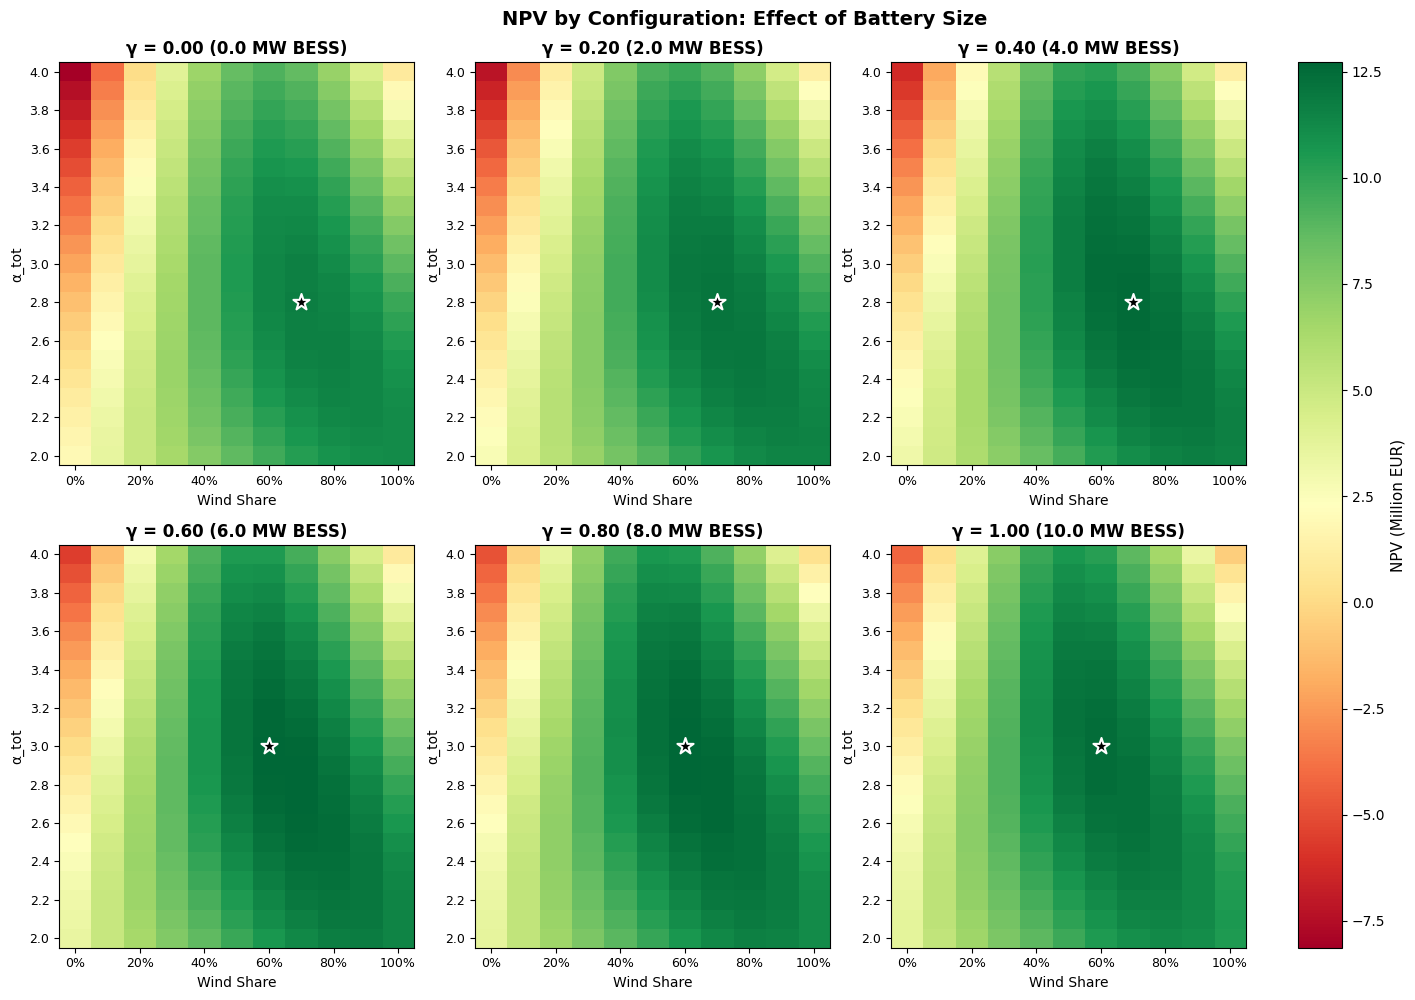

In [9]:
# Create NPV heatmaps for each gamma value
# Use 6 evenly spaced gamma values from 0 to 1
if 'pivot_heatmap' not in globals():
    from hybrid_bess_analysis import pivot_heatmap

gamma_values_plot = [round(x, 2) for x in np.linspace(0.0, 1.0, 6)]
n_gammas = len(gamma_values_plot)
n_cols = min(3, n_gammas)  # Max 3 columns
n_rows = (n_gammas + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
if n_gammas == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, gamma in enumerate(gamma_values_plot):
    ax = axes[idx]
    
    # Get data for this gamma
    npv_matrix = pivot_heatmap(
        df_results, 
        value_column='npv_eur',
        filter_column='gamma',
        filter_value=gamma,
    )
    
    # Plot heatmap
    im = ax.imshow(
        npv_matrix.values / 1e6,
        aspect='auto',
        origin='lower',
        cmap='RdYlGn',
        vmin=df_results['npv_eur'].min() / 1e6,
        vmax=df_results['npv_eur'].max() / 1e6,
    )
    
    # Set axis labels
    x_ticks = range(0, len(npv_matrix.columns), 2)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f"{npv_matrix.columns[i]:.0%}" for i in x_ticks], fontsize=9)
    
    y_ticks = range(0, len(npv_matrix.index), 2)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f"{npv_matrix.index[i]:.1f}" for i in y_ticks], fontsize=9)
    
    ax.set_xlabel("Wind Share", fontsize=10)
    ax.set_ylabel("α_tot", fontsize=10)
    
    bess_mw = gamma * POI_CAPACITY_MW
    ax.set_title(f"γ = {gamma:.2f} ({bess_mw:.1f} MW BESS)", fontsize=12, fontweight='bold')
    
    # Mark optimal for this gamma
    subset = df_results[df_results['gamma'] == gamma]
    if len(subset) > 0:
        best_idx = subset['npv_eur'].idxmax()
        best = subset.loc[best_idx]
        
        best_row = list(npv_matrix.index).index(best['alpha_tot'])
        best_col = list(npv_matrix.columns).index(best['s_wind'])
        ax.scatter([best_col], [best_row], color='black', s=150, marker='*', 
                   edgecolors='white', linewidths=1.5, zorder=5)

# Remove empty subplots
for idx in range(n_gammas, len(axes)):
    axes[idx].axis('off')

# Add colorbar - adjust layout first to leave room
plt.tight_layout(rect=[0, 0, 0.92, 0.98])  # Leave space on right (0.92) and top (0.98) for colorbar and suptitle
cbar = fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04)
cbar.set_label("NPV (Million EUR)", fontsize=11)
plt.suptitle("NPV by Configuration: Effect of Battery Size", fontsize=14, fontweight='bold', y=0.995)
plt.savefig(project_root / "pv_wind_bess_npv_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Best Configuration per Battery Size

Find and compare the optimal configuration for each battery size.


In [10]:
# Find best configuration for each gamma
best_by_gamma = []

for gamma in gamma_values:
    subset = [r for r in results if r.gamma == gamma]
    best = find_best_by_npv(subset)
    best_by_gamma.append(best)

# Create comparison table
comparison_data = {
    "γ (Battery Ratio)": [f"{b.gamma:.2f}" for b in best_by_gamma],
    "BESS Power (MW)": [f"{b.bess_power_mw:.1f}" for b in best_by_gamma],
    "BESS Energy (MWh)": [f"{b.bess_energy_mwh:.1f}" for b in best_by_gamma],
    "Optimal α_tot": [f"{b.alpha_tot:.2f}" for b in best_by_gamma],
    "Optimal s_wind": [f"{b.s_wind:.0%}" for b in best_by_gamma],
    "PV (MW)": [f"{b.pv_capacity_mw:.1f}" for b in best_by_gamma],
    "Wind (MW)": [f"{b.wind_capacity_mw:.1f}" for b in best_by_gamma],
    "NPV (€M)": [f"{b.npv_eur/1e6:.2f}" for b in best_by_gamma],
    "POI Util. (%)": [f"{b.poi_utilisation*100:.1f}" for b in best_by_gamma],
    "Curtailment (%)": [f"{b.curtailment_rate*100:.1f}" for b in best_by_gamma],
    "Cycles/yr": [f"{b.battery_cycles:.0f}" for b in best_by_gamma],
}

df_comparison = pd.DataFrame(comparison_data)

print("=" * 100)
print("OPTIMAL CONFIGURATION BY BATTERY SIZE")
print("=" * 100)
print(df_comparison.to_string(index=False))


OPTIMAL CONFIGURATION BY BATTERY SIZE
γ (Battery Ratio) BESS Power (MW) BESS Energy (MWh) Optimal α_tot Optimal s_wind PV (MW) Wind (MW) NPV (€M) POI Util. (%) Curtailment (%) Cycles/yr
             0.00             0.0               0.0          2.80            70%     8.4      19.6    11.67          53.0            16.6         0
             0.10             1.0               2.0          2.80            70%     8.4      19.6    11.90          53.4            16.0       300
             0.20             2.0               4.0          2.80            70%     8.4      19.6    12.13          53.6            15.5       300
             0.30             3.0               6.0          2.80            70%     8.4      19.6    12.34          53.9            15.0       300
             0.40             4.0               8.0          2.80            70%     8.4      19.6    12.50          54.1            14.6       300
             0.50             5.0              10.0          2.80         

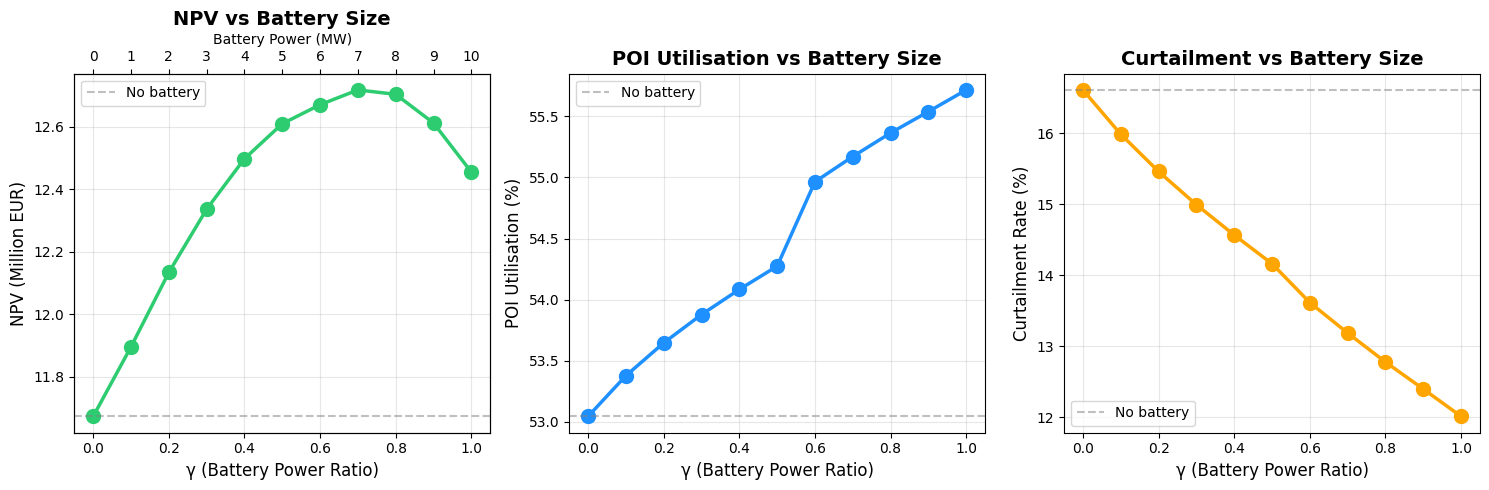

In [11]:
# Plot NPV vs Battery Size for optimal configurations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

gammas = [b.gamma for b in best_by_gamma]
npvs = [b.npv_eur / 1e6 for b in best_by_gamma]
poi_utils = [b.poi_utilisation * 100 for b in best_by_gamma]
curtailments = [b.curtailment_rate * 100 for b in best_by_gamma]

# Plot 1: NPV vs Battery Size
ax1 = axes[0]
ax1.plot(gammas, npvs, 'o-', color=bess_color, linewidth=2.5, markersize=10)
ax1.axhline(y=npvs[0], color='gray', linestyle='--', alpha=0.5, label='No battery')
ax1.set_xlabel("γ (Battery Power Ratio)", fontsize=12)
ax1.set_ylabel("NPV (Million EUR)", fontsize=12)
ax1.set_title("NPV vs Battery Size", fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Add secondary x-axis with MW
ax1_top = ax1.twiny()
ax1_top.set_xlim(ax1.get_xlim())
ax1_top.set_xticks(gammas)
ax1_top.set_xticklabels([f"{g * POI_CAPACITY_MW:.0f}" for g in gammas])
ax1_top.set_xlabel("Battery Power (MW)", fontsize=10)

# Plot 2: POI Utilisation vs Battery Size
ax2 = axes[1]
ax2.plot(gammas, poi_utils, 'o-', color=wind_color, linewidth=2.5, markersize=10)
ax2.axhline(y=poi_utils[0], color='gray', linestyle='--', alpha=0.5, label='No battery')
ax2.set_xlabel("γ (Battery Power Ratio)", fontsize=12)
ax2.set_ylabel("POI Utilisation (%)", fontsize=12)
ax2.set_title("POI Utilisation vs Battery Size", fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: Curtailment vs Battery Size
ax3 = axes[2]
ax3.plot(gammas, curtailments, 'o-', color=pv_color, linewidth=2.5, markersize=10)
ax3.axhline(y=curtailments[0], color='gray', linestyle='--', alpha=0.5, label='No battery')
ax3.set_xlabel("γ (Battery Power Ratio)", fontsize=12)
ax3.set_ylabel("Curtailment Rate (%)", fontsize=12)
ax3.set_title("Curtailment vs Battery Size", fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.savefig(project_root / "pv_wind_bess_battery_impact.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. NPV Sensitivity to Wind Share

How does NPV change with wind share for different battery sizes?


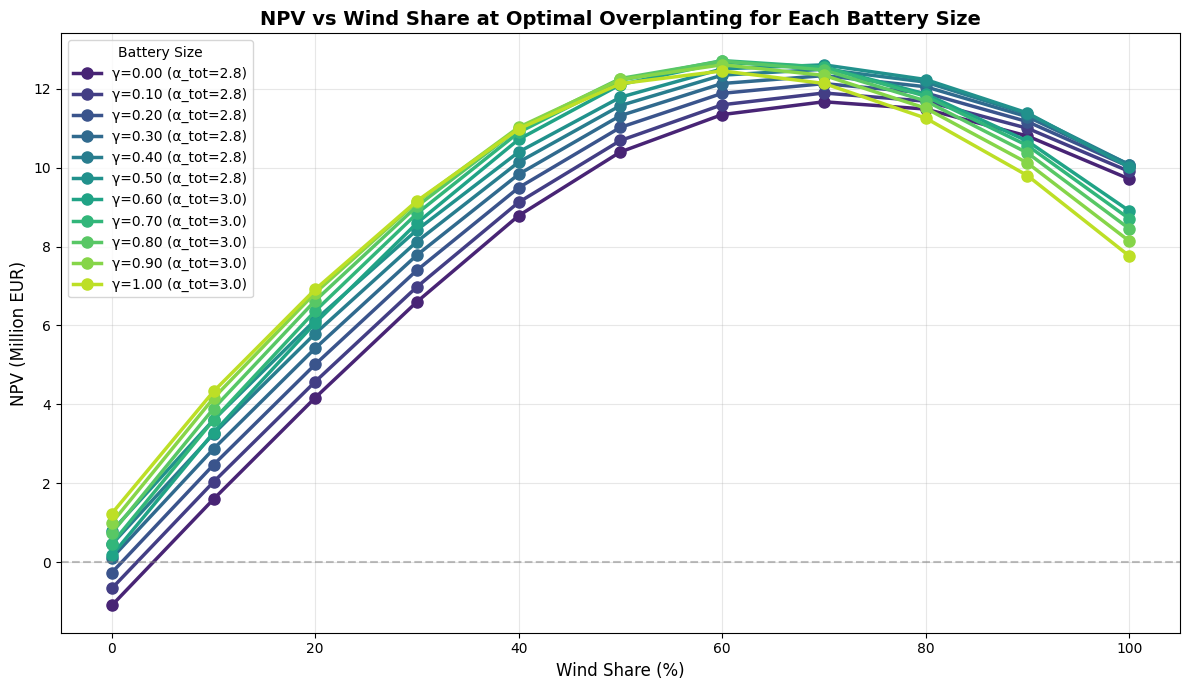

In [12]:
# NPV vs Wind Share at optimal α_tot for each gamma
fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(gamma_values)))

for idx, gamma in enumerate(gamma_values):
    # Find optimal alpha_tot for this gamma
    subset_gamma = df_results[df_results['gamma'] == gamma]
    best_alpha = subset_gamma.loc[subset_gamma['npv_eur'].idxmax(), 'alpha_tot']
    
    # Get NPV vs s_wind at this alpha
    subset = subset_gamma[subset_gamma['alpha_tot'] == best_alpha].sort_values('s_wind')
    
    label = f"γ={gamma:.2f} (α_tot={best_alpha:.1f})"
    ax.plot(
        subset['s_wind'] * 100, 
        subset['npv_eur'] / 1e6,
        'o-', 
        color=colors[idx], 
        linewidth=2.5, 
        markersize=8,
        label=label,
    )

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("Wind Share (%)", fontsize=12)
ax.set_ylabel("NPV (Million EUR)", fontsize=12)
ax.set_title("NPV vs Wind Share at Optimal Overplanting for Each Battery Size", fontsize=14, fontweight='bold')
ax.legend(title="Battery Size", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / "pv_wind_bess_npv_vs_wind_share.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. POI Utilisation Heatmaps

Visualize how battery storage improves POI utilisation.


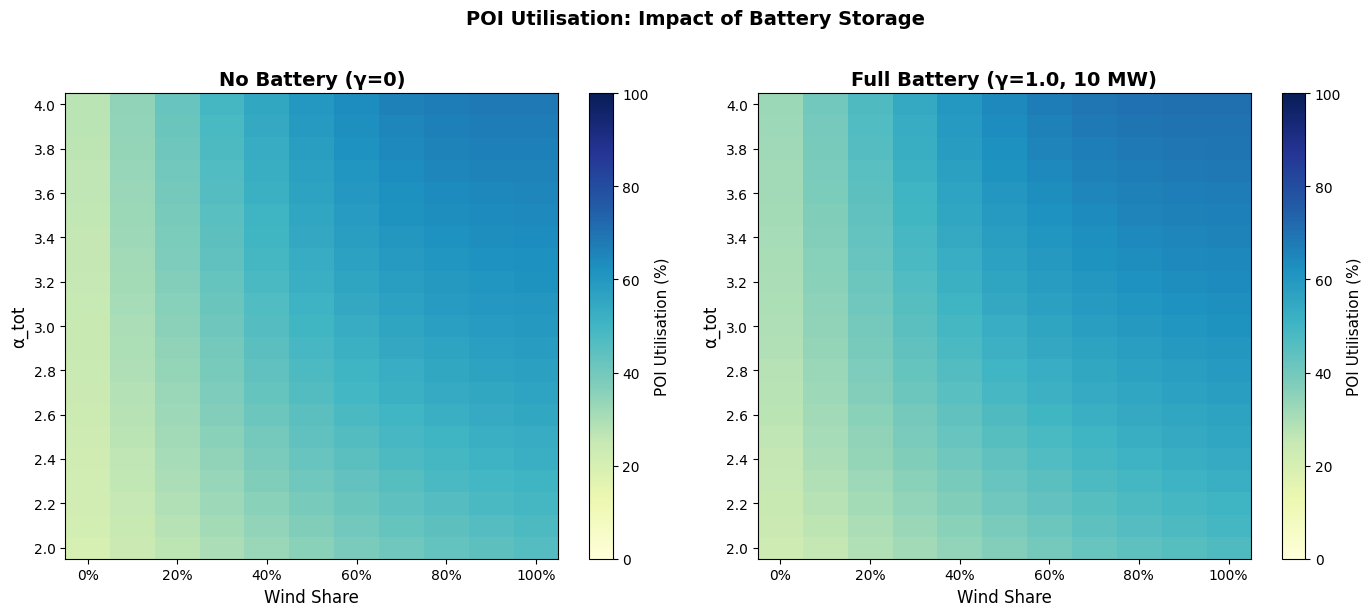

In [13]:
# Create POI utilisation heatmaps for no battery vs max battery
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, gamma in enumerate([0.0, 1.0]):
    ax = axes[idx]
    
    poi_matrix = pivot_heatmap(
        df_results,
        value_column='poi_utilisation',
        filter_column='gamma',
        filter_value=gamma,
    )
    
    im = ax.imshow(
        poi_matrix.values * 100,
        aspect='auto',
        origin='lower',
        cmap='YlGnBu',
        vmin=0,
        vmax=100,
    )
    
    x_ticks = range(0, len(poi_matrix.columns), 2)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f"{poi_matrix.columns[i]:.0%}" for i in x_ticks], fontsize=10)
    
    y_ticks = range(0, len(poi_matrix.index), 2)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f"{poi_matrix.index[i]:.1f}" for i in y_ticks], fontsize=10)
    
    ax.set_xlabel("Wind Share", fontsize=12)
    ax.set_ylabel("α_tot", fontsize=12)
    
    bess_mw = gamma * POI_CAPACITY_MW
    title = "No Battery (γ=0)" if gamma == 0 else f"Full Battery (γ=1.0, {bess_mw:.0f} MW)"
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("POI Utilisation (%)", fontsize=11)

plt.suptitle("POI Utilisation: Impact of Battery Storage", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(project_root / "pv_wind_bess_poi_utilisation.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Battery Value Analysis

How much NPV does the battery add compared to no-battery baseline?


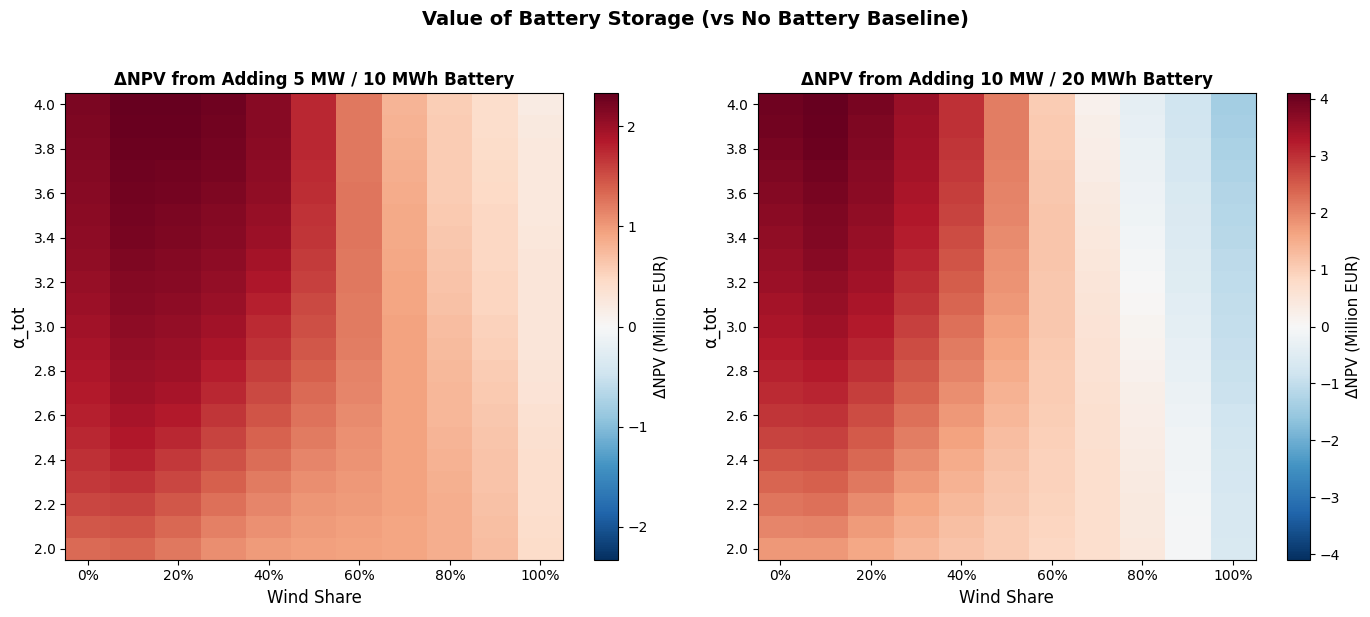

In [14]:
# Calculate NPV improvement from battery at each (alpha_tot, s_wind) point
df_no_batt = df_results[df_results['gamma'] == 0.0].set_index(['alpha_tot', 's_wind'])['npv_eur']

# Calculate delta NPV for each battery size
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, gamma in enumerate([0.5, 1.0]):
    ax = axes[idx]
    
    df_with_batt = df_results[df_results['gamma'] == gamma].copy()
    df_with_batt = df_with_batt.set_index(['alpha_tot', 's_wind'])
    
    delta_npv = df_with_batt['npv_eur'] - df_no_batt
    delta_npv = delta_npv.reset_index()
    delta_npv.columns = ['alpha_tot', 's_wind', 'delta_npv']
    
    delta_matrix = delta_npv.pivot(index='alpha_tot', columns='s_wind', values='delta_npv')
    
    # Create diverging colormap centered at 0
    vmax = max(abs(delta_matrix.values.min()), abs(delta_matrix.values.max()))
    norm = TwoSlopeNorm(vmin=-vmax/1e6, vcenter=0, vmax=vmax/1e6)
    
    im = ax.imshow(
        delta_matrix.values / 1e6,
        aspect='auto',
        origin='lower',
        cmap='RdBu_r',
        norm=norm,
    )
    
    x_ticks = range(0, len(delta_matrix.columns), 2)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f"{delta_matrix.columns[i]:.0%}" for i in x_ticks], fontsize=10)
    
    y_ticks = range(0, len(delta_matrix.index), 2)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f"{delta_matrix.index[i]:.1f}" for i in y_ticks], fontsize=10)
    
    ax.set_xlabel("Wind Share", fontsize=12)
    ax.set_ylabel("α_tot", fontsize=12)
    
    bess_mw = gamma * POI_CAPACITY_MW
    ax.set_title(f"ΔNPV from Adding {bess_mw:.0f} MW / {bess_mw*2:.0f} MWh Battery", fontsize=12, fontweight='bold')
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("ΔNPV (Million EUR)", fontsize=11)

plt.suptitle("Value of Battery Storage (vs No Battery Baseline)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(project_root / "pv_wind_bess_battery_value.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Detailed Results Summary

In [15]:
# Summary statistics
print("=" * 80)
print("SUMMARY STATISTICS BY BATTERY SIZE")
print("=" * 80)

for gamma in gamma_values:
    subset = df_results[df_results['gamma'] == gamma]
    print(f"\nγ = {gamma:.2f} ({gamma * POI_CAPACITY_MW:.0f} MW BESS):")
    print(f"  NPV range: €{subset['npv_eur'].min()/1e6:.2f}M to €{subset['npv_eur'].max()/1e6:.2f}M")
    print(f"  POI Util range: {subset['poi_utilisation'].min()*100:.1f}% to {subset['poi_utilisation'].max()*100:.1f}%")
    print(f"  Curtailment range: {subset['curtailment_rate'].min()*100:.1f}% to {subset['curtailment_rate'].max()*100:.1f}%")


SUMMARY STATISTICS BY BATTERY SIZE

γ = 0.00 (0 MW BESS):
  NPV range: €-8.13M to €11.67M
  POI Util range: 20.2% to 68.0%
  Curtailment range: 10.4% to 48.6%

γ = 0.10 (1 MW BESS):
  NPV range: €-7.65M to €11.90M
  POI Util range: 20.6% to 68.5%
  Curtailment range: 9.8% to 47.4%

γ = 0.20 (2 MW BESS):
  NPV range: €-7.20M to €12.13M
  POI Util range: 20.9% to 68.9%
  Curtailment range: 9.3% to 46.2%

γ = 0.30 (3 MW BESS):
  NPV range: €-6.76M to €12.34M
  POI Util range: 21.3% to 69.2%
  Curtailment range: 8.8% to 45.1%

γ = 0.40 (4 MW BESS):
  NPV range: €-6.34M to €12.50M
  POI Util range: 21.5% to 69.4%
  Curtailment range: 8.3% to 44.0%

γ = 0.50 (5 MW BESS):
  NPV range: €-5.94M to €12.61M
  POI Util range: 21.8% to 69.7%
  Curtailment range: 7.9% to 42.9%

γ = 0.60 (6 MW BESS):
  NPV range: €-5.54M to €12.67M
  POI Util range: 22.0% to 69.9%
  Curtailment range: 7.4% to 41.8%

γ = 0.70 (7 MW BESS):
  NPV range: €-5.17M to €12.72M
  POI Util range: 22.2% to 70.1%
  Curtailment r

In [16]:
# Best configurations comparison
print("\n" + "=" * 80)
print("TOP 10 CONFIGURATIONS BY NPV")
print("=" * 80)

top_10 = df_results.nlargest(10, 'npv_eur')[[
    'alpha_tot', 's_wind', 'gamma', 
    'pv_capacity_mw', 'wind_capacity_mw', 'bess_power_mw',
    'npv_eur', 'poi_utilisation', 'curtailment_rate'
]].copy()

top_10['npv_eur'] = top_10['npv_eur'] / 1e6
top_10['poi_utilisation'] = top_10['poi_utilisation'] * 100
top_10['curtailment_rate'] = top_10['curtailment_rate'] * 100
top_10.columns = ['α_tot', 's_wind', 'γ', 'PV (MW)', 'Wind (MW)', 'BESS (MW)', 'NPV (€M)', 'POI (%)', 'Curtail (%)']

print(top_10.to_string(index=False))



TOP 10 CONFIGURATIONS BY NPV
 α_tot  s_wind    γ  PV (MW)  Wind (MW)  BESS (MW)  NPV (€M)  POI (%)  Curtail (%)
  3.00    0.60 0.70    12.00      18.00       7.00     12.72    55.17        13.19
  2.90    0.60 0.70    11.60      17.40       7.00     12.71    53.82        12.36
  3.00    0.60 0.80    12.00      18.00       8.00     12.70    55.36        12.78
  2.90    0.60 0.80    11.60      17.40       8.00     12.69    54.01        11.96
  3.10    0.60 0.70    12.40      18.60       7.00     12.68    56.48        14.02
  3.00    0.60 0.60    12.00      18.00       6.00     12.67    54.96        13.62
  2.80    0.70 0.60     8.40      19.60       6.00     12.67    54.46        13.77
  3.10    0.60 0.80    12.40      18.60       8.00     12.67    56.68        13.62
  2.80    0.70 0.70     8.40      19.60       7.00     12.67    54.62        13.41
  2.90    0.60 0.60    11.60      17.40       6.00     12.67    53.63        12.78


## 10. Key Insights Summary


In [17]:
# Generate key insights
print("=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

# Best overall
print(f"\n1. OPTIMAL CONFIGURATION (Highest NPV):")
print(f"   - PV: {best_overall.pv_capacity_mw:.1f} MW, Wind: {best_overall.wind_capacity_mw:.1f} MW, BESS: {best_overall.bess_power_mw:.1f} MW/{best_overall.bess_energy_mwh:.1f} MWh")
print(f"   - NPV: €{best_overall.npv_eur/1e6:.2f}M")
print(f"   - POI Utilisation: {best_overall.poi_utilisation*100:.1f}%")

# Battery value
best_no_batt = find_best_by_npv([r for r in results if r.gamma == 0.0])
best_full_batt = find_best_by_npv([r for r in results if r.gamma == 1.0])
delta_npv_batt = best_full_batt.npv_eur - best_no_batt.npv_eur

print(f"\n2. BATTERY VALUE:")
print(f"   - Best NPV without battery: €{best_no_batt.npv_eur/1e6:.2f}M")
print(f"   - Best NPV with full battery (10 MW): €{best_full_batt.npv_eur/1e6:.2f}M")
print(f"   - NPV improvement: €{delta_npv_batt/1e6:.2f}M ({delta_npv_batt/best_no_batt.npv_eur*100:+.1f}%)")

# POI improvement
print(f"\n3. POI UTILISATION IMPROVEMENT:")
print(f"   - Without battery: {best_no_batt.poi_utilisation*100:.1f}%")
print(f"   - With full battery: {best_full_batt.poi_utilisation*100:.1f}%")
print(f"   - Improvement: {(best_full_batt.poi_utilisation - best_no_batt.poi_utilisation)*100:+.1f} percentage points")

# Curtailment reduction
print(f"\n4. CURTAILMENT REDUCTION:")
print(f"   - Without battery: {best_no_batt.curtailment_rate*100:.1f}%")
print(f"   - With full battery: {best_full_batt.curtailment_rate*100:.1f}%")
print(f"   - Reduction: {(best_no_batt.curtailment_rate - best_full_batt.curtailment_rate)*100:.1f} percentage points")


KEY INSIGHTS

1. OPTIMAL CONFIGURATION (Highest NPV):
   - PV: 12.0 MW, Wind: 18.0 MW, BESS: 7.0 MW/14.0 MWh
   - NPV: €12.72M
   - POI Utilisation: 55.2%

2. BATTERY VALUE:
   - Best NPV without battery: €11.67M
   - Best NPV with full battery (10 MW): €12.46M
   - NPV improvement: €0.78M (+6.7%)

3. POI UTILISATION IMPROVEMENT:
   - Without battery: 53.0%
   - With full battery: 55.7%
   - Improvement: +2.7 percentage points

4. CURTAILMENT REDUCTION:
   - Without battery: 16.6%
   - With full battery: 12.0%
   - Reduction: 4.6 percentage points


# 11. Deep Dive: Optimal Configuration Analysis

This section reconstructs the optimal scenario to visualize production curves, value of production, and battery cycling behavior.

In [18]:
# Load necessary data if not already in memory
if 'df' not in locals():
    print('Loading hourly data...')
    df = build_clean_dataset(
        wind_path=project_root / 'data_raw' / 'wind_data.csv',
        pv_path=project_root / 'data_raw' / 'pv_data.csv',
        price_path=project_root / 'data_raw' / 'price_data.csv',
    )
    if 'timestamp' in df.columns:
        df = df.set_index('timestamp')

# Determine optimal configuration
if 'best_overall' in locals():
    # If running in same session after grid search
    best_config = best_overall
elif 'df_results' in locals():
    # If df_results loaded but best_overall lost
    best_config = df_results.loc[df_results['npv_eur'].idxmax()]
else:
    # If starting fresh
    print('Loading results data...')
    try:
        df_results = pd.read_csv(project_root / 'data_processed' / 'pv_wind_bess_results.csv')
        best_config = df_results.loc[df_results['npv_eur'].idxmax()]
    except FileNotFoundError:
        print('Results file not found. Using default optimal parameters.')
        class Config: pass
        best_config = Config()
        best_config.alpha_tot = 2.6
        best_config.s_wind = 0.8
        best_config.gamma = 0.6
        best_config.npv_eur = 19390000

print('OPTIMAL CONFIGURATION:')
print(f'  α_tot: {best_config.alpha_tot}')
print(f'  s_wind: {best_config.s_wind:.0%}')
print(f'  γ: {best_config.gamma}')
print(f'  NPV: €{best_config.npv_eur/1e6:.2f}M')


OPTIMAL CONFIGURATION:
  α_tot: 3.0
  s_wind: 60%
  γ: 0.7
  NPV: €12.72M


In [20]:
# Re-run simulation for optimal configuration to get hourly data
from simulation_lp import simulate_pv_wind_bess_lp
from config import (
    POI_CAPACITY_MW, BESS_ROUNDTRIP_EFF
)

# Calculate capacities
alpha_tot = best_config.alpha_tot
s_wind = best_config.s_wind
gamma = best_config.gamma
poi_capacity_mw = POI_CAPACITY_MW

total_capacity_mw = alpha_tot * poi_capacity_mw
wind_capacity_mw = total_capacity_mw * s_wind
pv_capacity_mw = total_capacity_mw * (1.0 - s_wind)
bess_power_mw = gamma * poi_capacity_mw
bess_energy_mwh = bess_power_mw * 2.0 # Assuming 2h duration as per notebook defaults

# Prepare simulation
print("Re-running simulation for optimal configuration to get hourly details...")

# Prepare simulation dataframe
# Need to handle if index is already set or not
if df.index.name != 'timestamp' and 'timestamp' in df.columns:
    df = df.set_index('timestamp')

pv_gen_mw = df['pv_per_kw'].values * pv_capacity_mw
wind_gen_mw = df['wind_per_kw'].values * wind_capacity_mw

sim_df = pd.DataFrame({
    'pv_generation_mw': pv_gen_mw,
    'wind_generation_mw': wind_gen_mw,
    'day_ahead_price_eur_mwh': df['price_eur_per_mwh'].values,
}, index=df.index)

params = {
    'bess_cap_mwh': bess_energy_mwh,
    'bess_pwr_mw': bess_power_mw,
    'poi_mw': poi_capacity_mw,
    'eta_ch': np.sqrt(BESS_ROUNDTRIP_EFF),
    'eta_dis': np.sqrt(BESS_ROUNDTRIP_EFF),
}

# Run LP
optimal_dispatch = simulate_pv_wind_bess_lp(
    sim_df, params,
    time_limit_seconds=60,
    verbose=True
)

print("Simulation complete.")

display(optimal_dispatch.head())

Re-running simulation for optimal configuration to get hourly details...
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/fynnfroehlich/Master Thesis/.venv/lib/python3.9/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/2p/bk483h253013txglty1ym51m0000gn/T/a8592b832fc640c8bab50c2ff30db161-pulp.mps -max -sec 60 -timeMode elapsed -branch -printingOptions all -solution /var/folders/2p/bk483h253013txglty1ym51m0000gn/T/a8592b832fc640c8bab50c2ff30db161-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 35047 COLUMNS
At line 148866 RHS
At line 183909 BOUNDS
At line 218950 ENDATA
Problem MODEL has 35042 rows, 43800 columns and 105120 elements
Coin0008I MODEL read with 0 errors
seconds was changed from 1e+100 to 60
Option for timeMode changed from cpu to elapsed
Presolve 25940 (-9102) rows, 43229 (-571) columns and 95107 (-10013) elements
Perturbing problem by 0.001% of 936.28 - largest nonzero change

,charge_mw,charge_pv_mw,charge_wind_mw,discharge_mw,soc_mwh,export_mw,export_pv_mw,export_wind_mw,export_bess_mw,pv_generation_mw,wind_generation_mw,price_eur_mwh,revenue_eur,revenue_pv_eur,revenue_wind_eur,revenue_bess_eur,curtailment_mw,curtailment_pv_mw,curtailment_wind_mw
timestamp,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,-0.00,-0.00,-0.00,0.00,0.00,4.93,0.00,4.93,0.00,0.00,4.93,0.10,0.49,0.00,0.49,0.00,0.00,0.00,0.00
2024-01-01 01:00:00,0.00,0.00,0.00,0.00,0.00,4.41,0.00,4.41,0.00,0.00,4.41,0.01,0.04,0.00,0.04,0.00,0.00,0.00,0.00
2024-01-01 02:00:00,0.00,0.00,0.00,0.00,0.00,4.28,0.00,4.28,0.00,0.00,4.28,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2024-01-01 03:00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.32,-0.01,-0.00,-0.00,-0.00,-0.00,4.32,0.00,4.32
2024-01-01 04:00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.48,-0.03,-0.00,-0.00,-0.00,-0.00,4.48,0.00,4.48


### 11.1 Production Curves

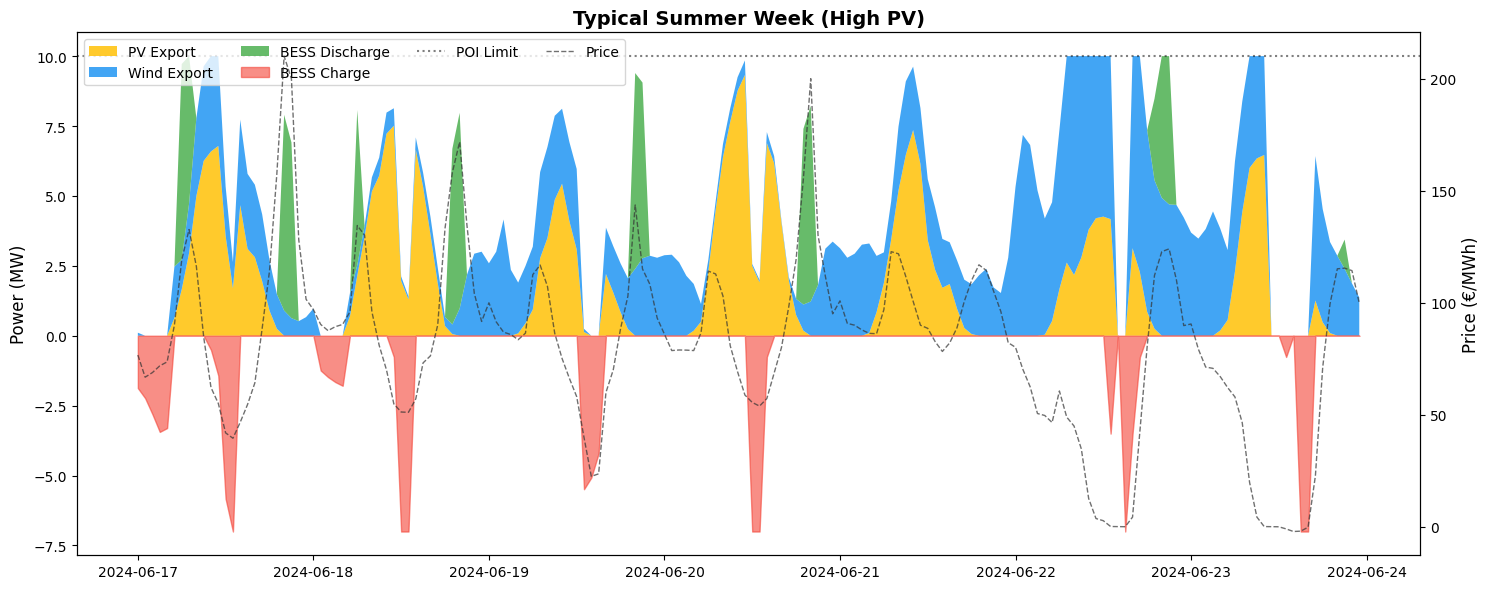

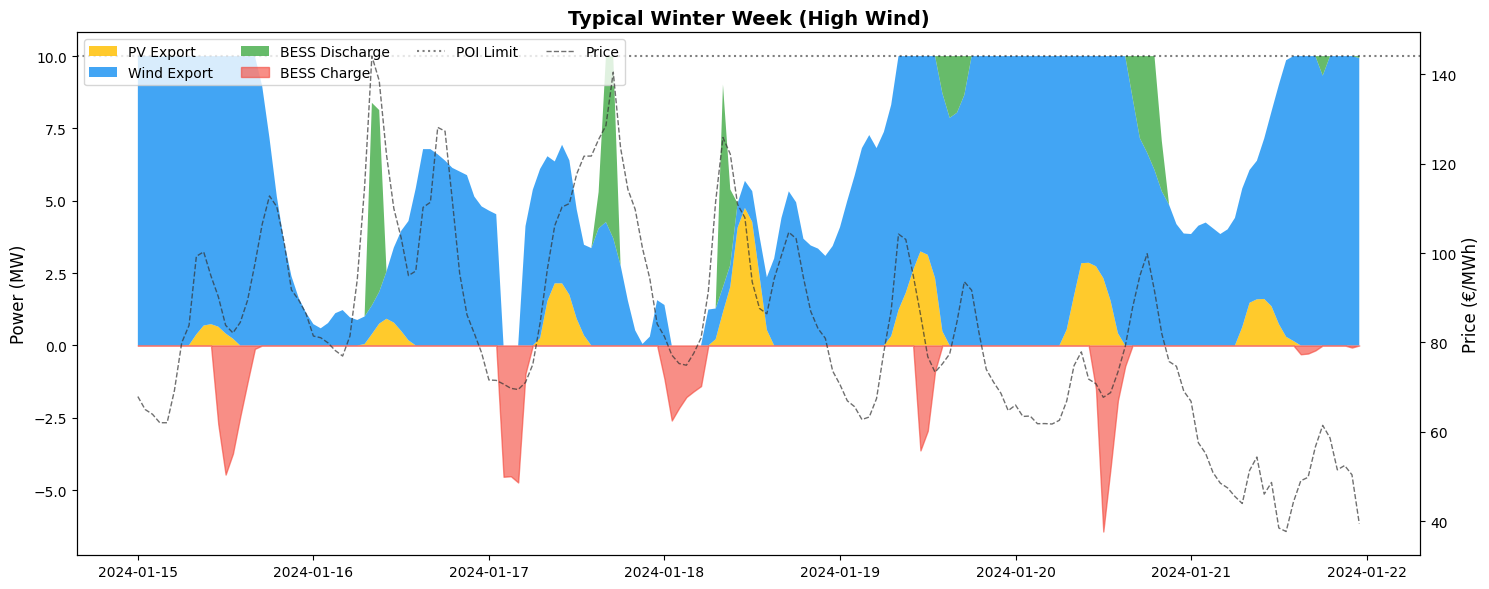

In [21]:
# Visualize Production Curves

def plot_dispatch_week(df_res, start_date_str, title):
    start_date = pd.Timestamp(start_date_str)
    end_date = start_date + pd.Timedelta(days=7)
    
    mask = (df_res.index >= start_date) & (df_res.index < end_date)
    subset = df_res[mask]
    
    if len(subset) == 0:
        print(f"No data for range {start_date} to {end_date}")
        return

    fig, ax1 = plt.subplots(figsize=(15, 6))
    
    x = subset.index
    
    # Stackplot for Exports (Generation)
    ax1.stackplot(x, 
        subset['export_pv_mw'], 
        subset['export_wind_mw'], 
        subset['discharge_mw'],
        labels=['PV Export', 'Wind Export', 'BESS Discharge'],
        colors=['#FFC107', '#2196F3', '#4CAF50'],
        alpha=0.85
    )
    
    # Charging (Negative)
    ax1.fill_between(x, 0, -subset['charge_mw'], color='#F44336', alpha=0.6, label='BESS Charge')
    
    # POI Limit
    ax1.axhline(y=poi_capacity_mw, color='k', linestyle=':', alpha=0.5, label='POI Limit')
    
    ax1.set_ylabel("Power (MW)", fontsize=12)
    
    # Secondary axis for Price
    ax2 = ax1.twinx()
    ax2.plot(x, subset['price_eur_mwh'], color='#333333', linestyle='--', linewidth=1, alpha=0.7, label='Price')
    ax2.set_ylabel("Price (€/MWh)", fontsize=12)
    
    # Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', ncol=4)
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Plot typical weeks
plot_dispatch_week(optimal_dispatch, "2024-06-17", "Typical Summer Week (High PV)")
plot_dispatch_week(optimal_dispatch, "2024-01-15", "Typical Winter Week (High Wind)")

### 11.2 Value of Production

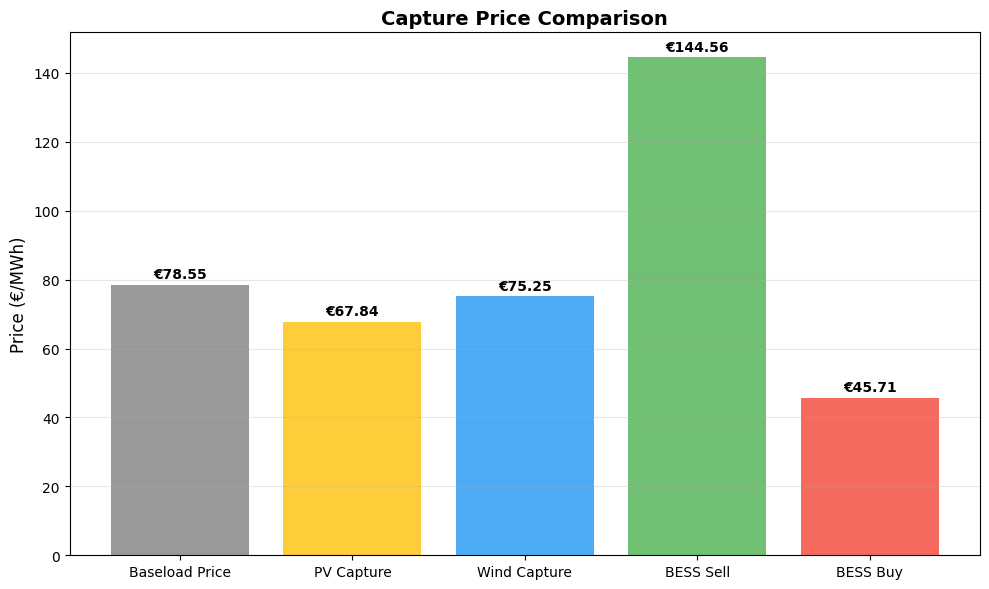

Relative to Baseload:
  PV Capture:   86.4%
  Wind Capture: 95.8%
  BESS Spread:  €98.85/MWh


In [22]:
# Value of Production Analysis

# 1. Capture Prices
vol_pv = optimal_dispatch['export_pv_mw'].sum()
vol_wind = optimal_dispatch['export_wind_mw'].sum()
vol_bess_discharge = optimal_dispatch['discharge_mw'].sum()
vol_bess_charge = optimal_dispatch['charge_mw'].sum()

rev_pv = optimal_dispatch['revenue_pv_eur'].sum()
rev_wind = optimal_dispatch['revenue_wind_eur'].sum()

avg_price = optimal_dispatch['price_eur_mwh'].mean()
cap_price_pv = rev_pv / vol_pv if vol_pv > 0 else 0
cap_price_wind = rev_wind / vol_wind if vol_wind > 0 else 0

# BESS realized prices
avg_sell_price = (optimal_dispatch['discharge_mw'] * optimal_dispatch['price_eur_mwh']).sum() / vol_bess_discharge if vol_bess_discharge > 0 else 0
avg_buy_price = (optimal_dispatch['charge_mw'] * optimal_dispatch['price_eur_mwh']).sum() / vol_bess_charge if vol_bess_charge > 0 else 0

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Baseload Price', 'PV Capture', 'Wind Capture', 'BESS Sell', 'BESS Buy']
values = [avg_price, cap_price_pv, cap_price_wind, avg_sell_price, avg_buy_price]
colors = ['gray', '#FFC107', '#2196F3', '#4CAF50', '#F44336']

bars = ax.bar(metrics, values, color=colors, alpha=0.8)

# Labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'€{height:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel("Price (€/MWh)", fontsize=12)
ax.set_title("Capture Price Comparison", fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Relative to Baseload:")
print(f"  PV Capture:   {cap_price_pv/avg_price:.1%}")
print(f"  Wind Capture: {cap_price_wind/avg_price:.1%}")
print(f"  BESS Spread:  €{avg_sell_price - avg_buy_price:.2f}/MWh")

### 11.3 Battery Cycles

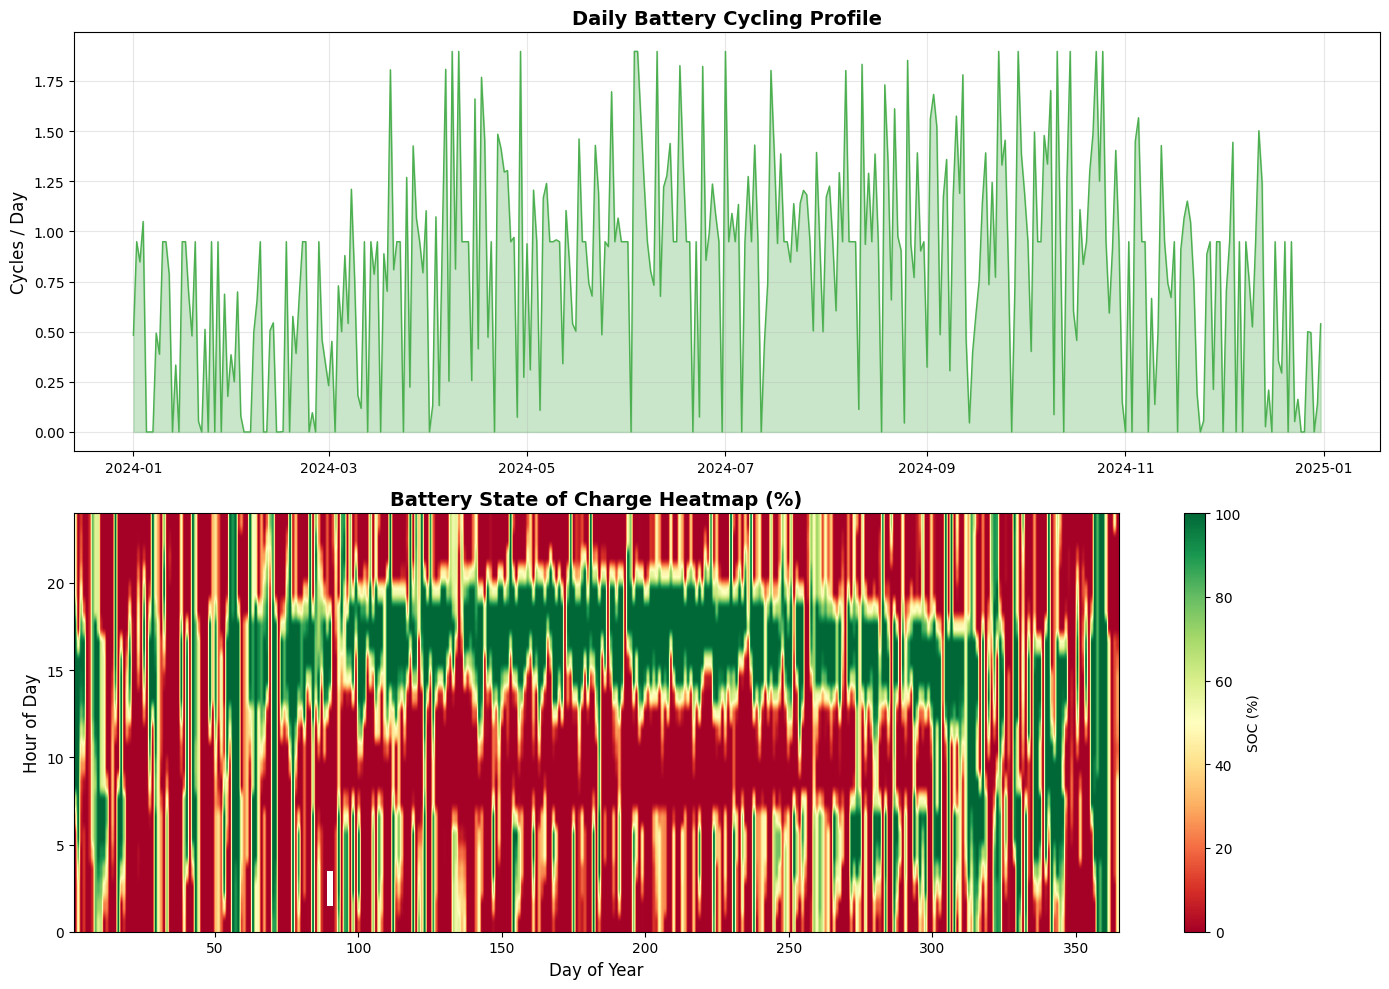

Total Annual Cycles: 300.0


In [23]:
# BESS Cycles Analysis

# Daily Cycles
optimal_dispatch['date'] = optimal_dispatch.index.date
daily_cycles = optimal_dispatch.groupby('date')['discharge_mw'].sum() / params['bess_cap_mwh']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# 1. Daily Cycles Line Plot
ax1.plot(daily_cycles.index, daily_cycles, color='#4CAF50', linewidth=1)
ax1.fill_between(daily_cycles.index, daily_cycles, color='#4CAF50', alpha=0.3)
ax1.set_ylabel("Cycles / Day", fontsize=12)
ax1.set_title("Daily Battery Cycling Profile", fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. SOC Heatmap
df_hm = optimal_dispatch.copy()
df_hm['day_of_year'] = df_hm.index.dayofyear
df_hm['hour'] = df_hm.index.hour

soc_pivot = df_hm.pivot_table(
    values='soc_mwh', 
    index='hour', 
    columns='day_of_year'
)
soc_pct = soc_pivot / params['bess_cap_mwh'] * 100

im = ax2.imshow(soc_pct, aspect='auto', cmap='RdYlGn', origin='lower', extent=[1, 365, 0, 24])
ax2.set_ylabel("Hour of Day", fontsize=12)
ax2.set_xlabel("Day of Year", fontsize=12)
ax2.set_title("Battery State of Charge Heatmap (%)", fontsize=14, fontweight='bold')
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label("SOC (%)")

plt.tight_layout()
plt.show()

print(f"Total Annual Cycles: {daily_cycles.sum():.1f}")